<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №8. Генеративно-состязательная сеть (GAN)**

---
**❗ Примечание:**

Не забывайте периодически сохранять параметры модели. Функции для этого описаны в теоретической части. В случае приостановки процесса обучения из-за перегрузки ОЗУ, Вы сможете загрузить последние предобученные параметры и продолжить обучение.

---

## **Задание №1.** Обучите генератор воспризводить примитивные изображения. Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))





In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

print("TensorFlow version:", tf.__version__)

LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 30
SAVE_DIR = "gan_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

TensorFlow version: 2.19.0


In [2]:
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(buffer_size=60000).batch(BATCH_SIZE, drop_remainder=True)

print("Форма обучающей выборки:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Форма обучающей выборки: (60000, 28, 28, 1)


In [3]:
def build_generator(latent_dim=100):
    model = tf.keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding="same", use_bias=False, activation="tanh")
    ])
    return model

generator = build_generator(LATENT_DIM)
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [4]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, kernel_size=5, strides=2, padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, kernel_size=5, strides=2, padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [6]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [7]:
seed = tf.random.normal([16, LATENT_DIM])

def train(dataset, epochs):
    for epoch in range(epochs):
        gen_losses = []
        disc_losses = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            gen_losses.append(gen_loss.numpy())
            disc_losses.append(disc_loss.numpy())

        print(f"Эпоха {epoch+1}/{epochs} | G loss: {np.mean(gen_losses):.4f} | D loss: {np.mean(disc_losses):.4f}")

        if (epoch + 1) % 10 == 0:
            generator.save_weights(os.path.join(SAVE_DIR, f"generator_epoch_{epoch+1}.weights.h5"))
            discriminator.save_weights(os.path.join(SAVE_DIR, f"discriminator_epoch_{epoch+1}.weights.h5"))

train(dataset, EPOCHS)

Эпоха 1/30 | G loss: 0.8700 | D loss: 1.1530
Эпоха 2/30 | G loss: 0.9145 | D loss: 1.2015
Эпоха 3/30 | G loss: 0.8256 | D loss: 1.3040
Эпоха 4/30 | G loss: 0.9915 | D loss: 1.2097
Эпоха 5/30 | G loss: 0.9453 | D loss: 1.2045
Эпоха 6/30 | G loss: 0.8868 | D loss: 1.2520
Эпоха 7/30 | G loss: 1.1361 | D loss: 1.0669
Эпоха 8/30 | G loss: 1.0161 | D loss: 1.1267
Эпоха 9/30 | G loss: 1.2425 | D loss: 0.9778
Эпоха 10/30 | G loss: 1.3657 | D loss: 0.8651
Эпоха 11/30 | G loss: 1.4385 | D loss: 0.9045
Эпоха 12/30 | G loss: 1.5477 | D loss: 0.8091
Эпоха 13/30 | G loss: 1.5800 | D loss: 0.7858
Эпоха 14/30 | G loss: 1.7874 | D loss: 0.7833
Эпоха 15/30 | G loss: 1.6843 | D loss: 0.7588
Эпоха 16/30 | G loss: 1.6007 | D loss: 0.8267
Эпоха 17/30 | G loss: 1.6805 | D loss: 0.7811
Эпоха 18/30 | G loss: 1.6018 | D loss: 0.8544
Эпоха 19/30 | G loss: 1.6219 | D loss: 0.8277
Эпоха 20/30 | G loss: 1.5643 | D loss: 0.8352
Эпоха 21/30 | G loss: 1.6595 | D loss: 0.8356
Эпоха 22/30 | G loss: 1.5066 | D loss: 0.89

### **Демонстрация сгенерированных изображений:**

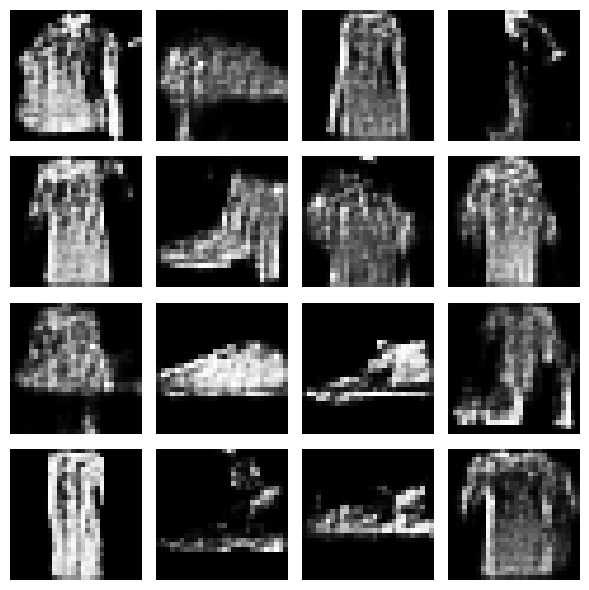

In [8]:
def generate_and_plot_images(model, test_input, n=16):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1.0) / 2.0

    plt.figure(figsize=(6, 6))
    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

generate_and_plot_images(generator, seed)

---

## **Задание №2.** Обучите генератор воспризводить примитивные изображения по заданному условию (Conditional Generative Adversarial Nets (CGAN)).



(На вход генератора подается вектор случайного шума и метка класса - на выходе должно получиться изображение, соответствующее данному классу)



Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

NUM_CLASSES = 10
LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 30

(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

y_train = y_train.astype("int32")

dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
dataset = dataset.shuffle(60000).batch(BATCH_SIZE, drop_remainder=True)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [10]:
def build_cgan_generator(latent_dim, num_classes):
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(1,), dtype="int32")

    label_embedding = layers.Embedding(num_classes, latent_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    x = layers.Concatenate()([noise_input, label_embedding])

    x = layers.Dense(7 * 7 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(128, 5, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    output = layers.Conv2DTranspose(1, 5, strides=2, padding="same", activation="tanh")(x)

    return tf.keras.Model([noise_input, label_input], output)

cgan_generator = build_cgan_generator(LATENT_DIM, NUM_CLASSES)
cgan_generator.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 100)    │      1,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 100)       │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200)       │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12544)     │  2,508,800 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12544)     │     50,176 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 12544)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 256) │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 7, 7, 128) │    819,200 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 14, 14,    │    204,800 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 28, 28, 1) │      1,601 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,586,345 (13.68 MB)

 Trainable params: 3,560,873 (13.58 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [11]:
def build_cgan_discriminator(num_classes):
    image_input = layers.Input(shape=(28, 28, 1))
    label_input = layers.Input(shape=(1,), dtype="int32")

    label_embedding = layers.Embedding(num_classes, 28 * 28)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    label_embedding = layers.Reshape((28, 28, 1))(label_embedding)

    x = layers.Concatenate()([image_input, label_embedding])

    x = layers.Conv2D(64, 5, strides=2, padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 5, strides=2, padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    output = layers.Dense(1)(x)

    return tf.keras.Model([image_input, label_input], output)

cgan_discriminator = build_cgan_discriminator(NUM_CLASSES)
cgan_discriminator.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 784)    │      7,840 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │      3,264 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 14,    │          0 │ leaky_re_lu_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 128) │    204,928 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 7, 7, 128) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 6272)      │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │      6,273 │ flatten_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 222,305 (868.38 KB)

 Trainable params: 222,305 (868.38 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def g_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

g_optimizer = tf.keras.optimizers.Adam(1e-4)
d_optimizer = tf.keras.optimizers.Adam(1e-4)

In [13]:
@tf.function
def train_cgan_step(images, labels):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])
    labels = tf.reshape(labels, (-1, 1))

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = cgan_generator([noise, labels], training=True)

        real_output = cgan_discriminator([images, labels], training=True)
        fake_output = cgan_discriminator([generated_images, labels], training=True)

        gen_loss = g_loss(fake_output)
        disc_loss = d_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, cgan_generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, cgan_discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_of_generator, cgan_generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_of_discriminator, cgan_discriminator.trainable_variables))

    return gen_loss, disc_loss

In [14]:
def train_cgan(dataset, epochs):
    for epoch in range(epochs):
        gen_losses = []
        disc_losses = []

        for image_batch, label_batch in dataset:
            gen_loss, disc_loss = train_cgan_step(image_batch, label_batch)
            gen_losses.append(gen_loss.numpy())
            disc_losses.append(disc_loss.numpy())

        print(f"Эпоха {epoch+1}/{epochs} | G loss: {np.mean(gen_losses):.4f} | D loss: {np.mean(disc_losses):.4f}")

train_cgan(dataset, EPOCHS)

Эпоха 1/30 | G loss: 0.8449 | D loss: 1.1581
Эпоха 2/30 | G loss: 0.9390 | D loss: 1.1885
Эпоха 3/30 | G loss: 0.8344 | D loss: 1.2981
Эпоха 4/30 | G loss: 0.8243 | D loss: 1.2674
Эпоха 5/30 | G loss: 0.8955 | D loss: 1.2532
Эпоха 6/30 | G loss: 0.8626 | D loss: 1.2348
Эпоха 7/30 | G loss: 0.9514 | D loss: 1.1735
Эпоха 8/30 | G loss: 0.9786 | D loss: 1.1463
Эпоха 9/30 | G loss: 1.0280 | D loss: 1.1607
Эпоха 10/30 | G loss: 0.9873 | D loss: 1.1559
Эпоха 11/30 | G loss: 1.0947 | D loss: 1.0625
Эпоха 12/30 | G loss: 1.0998 | D loss: 1.1001
Эпоха 13/30 | G loss: 1.1909 | D loss: 1.0208
Эпоха 14/30 | G loss: 1.2923 | D loss: 0.9539
Эпоха 15/30 | G loss: 1.2750 | D loss: 0.9841
Эпоха 16/30 | G loss: 1.1841 | D loss: 1.0732
Эпоха 17/30 | G loss: 1.2821 | D loss: 0.9613
Эпоха 18/30 | G loss: 1.2774 | D loss: 0.9778
Эпоха 19/30 | G loss: 1.3275 | D loss: 0.9674
Эпоха 20/30 | G loss: 1.3401 | D loss: 0.9408
Эпоха 21/30 | G loss: 1.2725 | D loss: 1.0158
Эпоха 22/30 | G loss: 1.2203 | D loss: 1.04

### **Демонстрация сгенерированных изображений:**

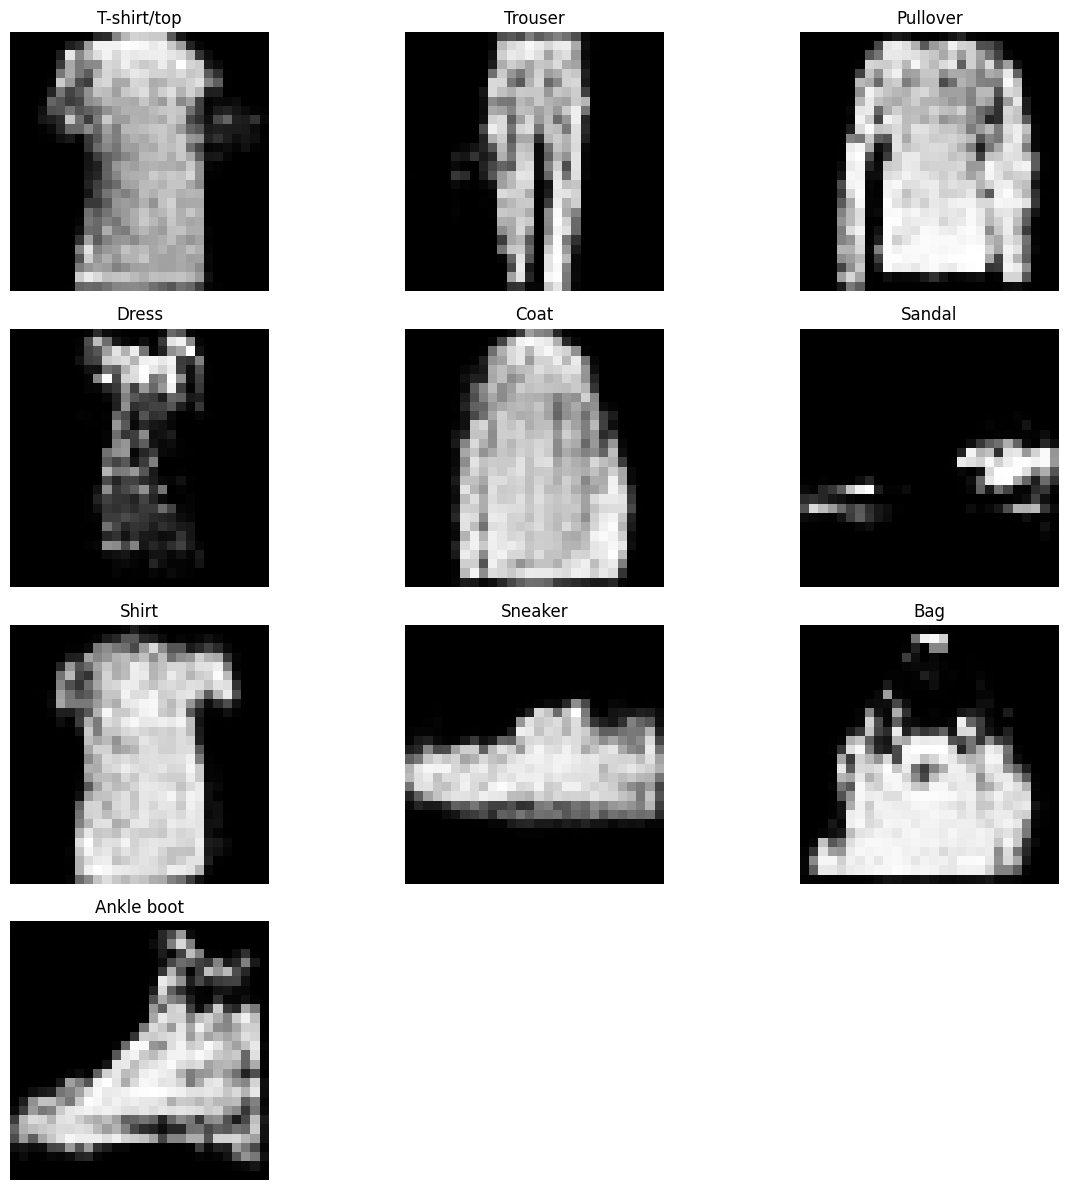

In [15]:
def plot_cgan_results(generator, latent_dim, num_classes):
    plt.figure(figsize=(12, 12))

    for i in range(num_classes):
        noise = tf.random.normal([1, latent_dim])
        label = tf.constant([[i]])
        generated_image = generator([noise, label], training=False)
        generated_image = (generated_image[0, :, :, 0] + 1.0) / 2.0

        plt.subplot(4, 3, i + 1)
        plt.imshow(generated_image, cmap="gray")
        plt.title(class_names[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_cgan_results(cgan_generator, LATENT_DIM, NUM_CLASSES)

---

## **Задание №3.** Обучите генератор колоризировать изображения из выбранного Вами датасета (можете использовать датасет из работы №6, в которой Вы решали аналогичную задачу).

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = 32
BATCH_SIZE = 128
EPOCHS = 20

In [17]:
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_gray = tf.image.rgb_to_grayscale(x_train).numpy()
x_test_gray = tf.image.rgb_to_grayscale(x_test).numpy()

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_gray, x_train))
train_dataset = train_dataset.shuffle(50000).batch(BATCH_SIZE)

print("Серые изображения:", x_train_gray.shape)
print("Цветные изображения:", x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Серые изображения: (50000, 32, 32, 1)
Цветные изображения: (50000, 32, 32, 3)


In [18]:
def build_colorization_generator():
    inputs = layers.Input(shape=(32, 32, 1))

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)
    return model

colorizer = build_colorization_generator()
colorizer.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,227 (2.82 MB)

 Trainable params: 740,227 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
colorizer.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mae",
    metrics=["mse"]
)

history = colorizer.fit(
    train_dataset,
    epochs=EPOCHS
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - loss: 0.0832 - mse: 0.0137
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0628 - mse: 0.0080
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0586 - mse: 0.0072
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0565 - mse: 0.0068
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0552 - mse: 0.0066
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0544 - mse: 0.0064
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0536 - mse: 0.0063
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0530 - mse: 0.0062
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0523 - mse: 0.0061
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0521 - mse: 0.0061
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0517 - mse: 0.0060
Epoch 12/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0514 - mse: 0.0060
E

### **Демонстрация сгенерированных изображений:**

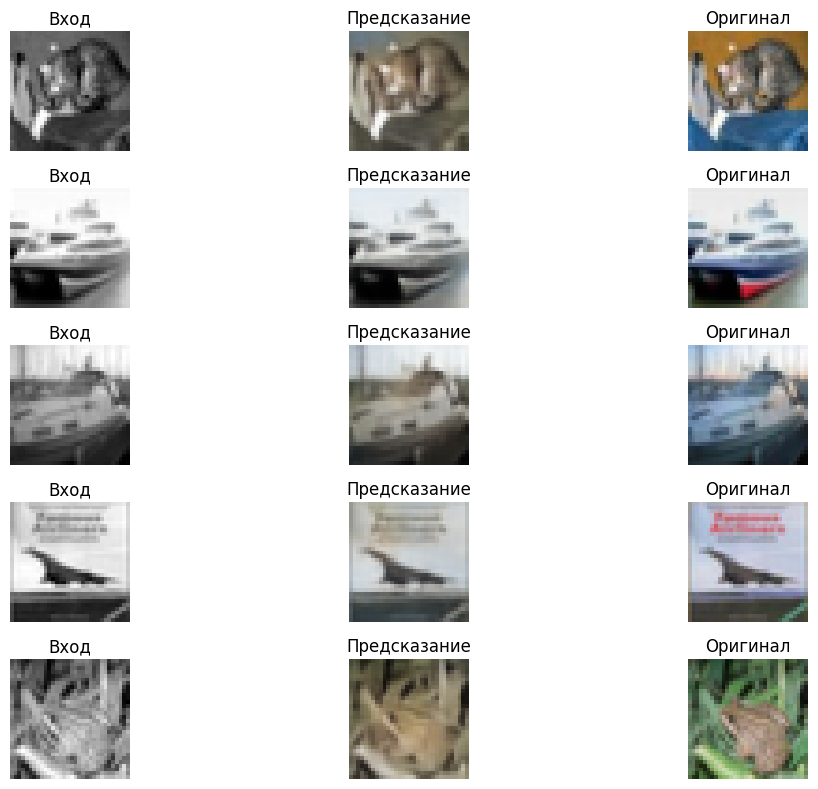

In [21]:
def show_colorization_results(model, gray_images, color_images, n=5):
    preds = model.predict(gray_images[:n], verbose=0)

    plt.figure(figsize=(12, 8))
    for i in range(n):
        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(gray_images[i].squeeze(), cmap="gray")
        plt.title("Вход")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(preds[i])
        plt.title("Предсказание")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(color_images[i])
        plt.title("Оригинал")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_colorization_results(colorizer, x_test_gray, x_test, n=5)

---

## **Задание №4.** Обучите генератор воспроизводить изображения из выбранного Вами датасета (pix2pix).



---
Примеры таких датасетов представлены на сайтах [kaggle.com](https://www.kaggle.com/search?q=pix2pix+in%3Adatasets+datasetFileTypes%3Ajpg+datasetFileTypes%3Apng) и [efrosgans.eecs.berkeley.edu*](http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/).

**\*Калифорнийский университет Беркли (UC Berkeley) внесён в реестр организаций, деятельность которых признана нежелательной в России.**


---

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = 32
BATCH_SIZE = 64
EPOCHS = 20
LAMBDA = 100

In [23]:
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_input = tf.image.rgb_to_grayscale(x_train).numpy()
x_test_input = tf.image.rgb_to_grayscale(x_test).numpy()

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_input, x_train))
train_dataset = train_dataset.shuffle(50000).batch(BATCH_SIZE)

print("Вход:", x_train_input.shape)
print("Цель:", x_train.shape)

Вход: (50000, 32, 32, 1)
Цель: (50000, 32, 32, 3)


In [24]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                      kernel_initializer=initializer, use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

def build_pix2pix_generator():
    inputs = layers.Input(shape=[32, 32, 1])

    down1 = downsample(64, 4, apply_batchnorm=False)(inputs)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    up1 = upsample(128, 4)(down3)
    up1 = layers.Concatenate()([up1, down2])

    up2 = upsample(64, 4)(up1)
    up2 = layers.Concatenate()([up2, down1])

    initializer = tf.random_normal_initializer(0., 0.02)
    outputs = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                     kernel_initializer=initializer,
                                     activation='sigmoid')(up2)

    return tf.keras.Model(inputs=inputs, outputs=outputs)

pix2pix_generator = build_pix2pix_generator()
pix2pix_generator.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 16, 16,    │      1,024 │ input_layer_7[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 8, 8, 128) │    131,584 │ sequential_2[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 4, 4, 256) │    525,312 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 8, 8, 128) │    524,800 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 256) │          0 │ sequential_5[0][… │
│ (Concatenate)       │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 16, 16,    │    262,400 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_6[0][… │
│ (Concatenate)       │ 128)              │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 32, 32, 3) │      6,147 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,451,267 (5.54 MB)

 Trainable params: 1,450,115 (5.53 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [25]:
def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = layers.Input(shape=[32, 32, 1], name='input_image')
    tar = layers.Input(shape=[32, 32, 3], name='target_image')

    x = layers.Concatenate()([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = layers.ZeroPadding2D()(down3)
    conv = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)
    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(zero_pad2)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

pix2pix_discriminator = build_discriminator()
pix2pix_discriminator.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_image        │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32, 4) │          0 │ input_image[0][0… │
│ (Concatenate)       │                   │            │ target_image[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 16, 16,    │      4,096 │ concatenate_4[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 8, 8, 128) │    131,584 │ sequential_7[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 4, 4, 256) │    525,312 │ sequential_8[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 6, 6, 256) │          0 │ sequential_9[0][… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 3, 3, 512) │  2,097,152 │ zero_padding2d[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 3, 512) │      2,048 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 3, 3, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 5, 5, 512) │          0 │ leaky_re_lu_16[0… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 2, 2, 1)   │      8,193 │ zero_padding2d_1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,768,385 (10.56 MB)

 Trainable params: 2,766,593 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [26]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss, gan_loss, l1_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [27]:
@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = pix2pix_generator(input_image, training=True)

        disc_real_output = pix2pix_discriminator([input_image, target], training=True)
        disc_generated_output = pix2pix_discriminator([input_image, gen_output], training=True)

        total_gen_loss, gan_loss, l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(total_gen_loss, pix2pix_generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, pix2pix_discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, pix2pix_generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, pix2pix_discriminator.trainable_variables))

    return total_gen_loss, disc_loss

In [28]:
def fit_pix2pix(train_ds, epochs):
    for epoch in range(epochs):
        gen_losses = []
        disc_losses = []

        for input_image, target in train_ds:
            gen_loss, disc_loss = train_step(input_image, target)
            gen_losses.append(gen_loss.numpy())
            disc_losses.append(disc_loss.numpy())

        print(f"Эпоха {epoch+1}/{epochs} | G loss: {np.mean(gen_losses):.4f} | D loss: {np.mean(disc_losses):.4f}")

fit_pix2pix(train_dataset, EPOCHS)

Эпоха 1/20 | G loss: 9.6257 | D loss: 0.9743
Эпоха 2/20 | G loss: 9.1211 | D loss: 0.6850
Эпоха 3/20 | G loss: 9.5131 | D loss: 0.5519
Эпоха 4/20 | G loss: 9.8801 | D loss: 0.4870
Эпоха 5/20 | G loss: 9.9868 | D loss: 0.4424
Эпоха 6/20 | G loss: 9.9887 | D loss: 0.4514
Эпоха 7/20 | G loss: 10.0785 | D loss: 0.4230
Эпоха 8/20 | G loss: 9.9407 | D loss: 0.4490
Эпоха 9/20 | G loss: 10.0253 | D loss: 0.4390
Эпоха 10/20 | G loss: 10.1760 | D loss: 0.3774
Эпоха 11/20 | G loss: 10.2922 | D loss: 0.3964
Эпоха 12/20 | G loss: 10.3448 | D loss: 0.3412
Эпоха 13/20 | G loss: 10.4808 | D loss: 0.3539
Эпоха 14/20 | G loss: 10.3614 | D loss: 0.3563
Эпоха 15/20 | G loss: 10.6690 | D loss: 0.3030
Эпоха 16/20 | G loss: 10.7111 | D loss: 0.2814
Эпоха 17/20 | G loss: 10.7624 | D loss: 0.3128
Эпоха 18/20 | G loss: 10.8386 | D loss: 0.2898
Эпоха 19/20 | G loss: 10.9281 | D loss: 0.2821
Эпоха 20/20 | G loss: 10.9818 | D loss: 0.3008


### **Демонстрация сгенерированных изображений:**

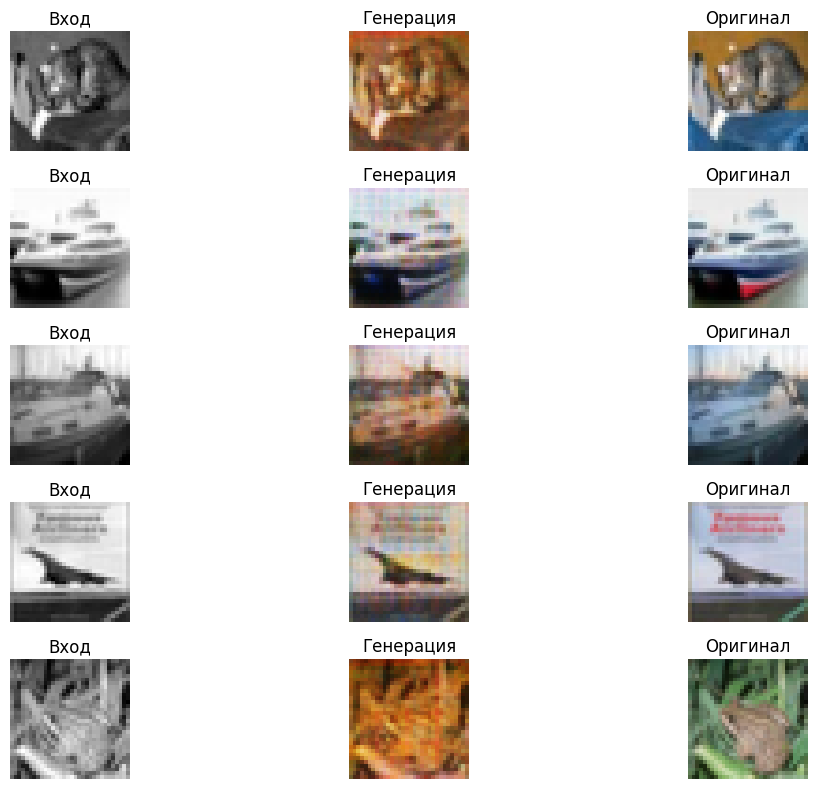

In [30]:
def show_pix2pix_results(model, inputs, targets, n=5):
    preds = model.predict(inputs[:n], verbose=0)

    plt.figure(figsize=(12, 8))
    for i in range(n):
        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(inputs[i].squeeze(), cmap="gray")
        plt.title("Вход")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(preds[i])
        plt.title("Генерация")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(targets[i])
        plt.title("Оригинал")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_pix2pix_results(pix2pix_generator, x_test_input, x_test, n=5)